In [1]:
import numpy as np
#if this fails, you need to put the case_studies.py file in the same folder
from case_studies import *

In [2]:
from scipy.optimize import minimize

#These are the example optimizers you should evaluate this week.
#These are optimizers implemented in scipy.
#they take as first 2 or 3 arguments the function f, its gradient df and sometimes its hessian Hf.
#the next parameters are all the same: x0 is the starting point, max_iterations the stopping criterion for iterations
#and epsilon the precision tolerance to be reached. 
#Note: epsilon is interpreted slightly differently across algorithms, and some algorithms might not reach the tolerance
#and stop early.
def scipy_bfgs(f,df,x0,max_iterations,epsilon):
    xs=[]
    grad_norms=[]
    def logging_f(x):
        xs.append(x)
        grad_norms.append(np.maximum(np.linalg.norm(df(x)),10**(-5)*epsilon))
        return f(x)
    minimize(logging_f, x0, method="BFGS", jac=df, tol=epsilon,options={'maxiter':max_iterations, 'gtol':epsilon})
    return np.array(xs), np.array(grad_norms)

def scipy_newton(f,df,Hf,x0,max_iterations,epsilon):
    xs=[]
    grad_norms=[]
    def logging_f(x):
        xs.append(x)
        grad_norms.append(np.maximum(np.linalg.norm(df(x)),10**(-5)*epsilon))
        return f(x)
    minimize(logging_f, x0, method="Newton-CG", jac=df, hess=Hf, tol=epsilon,options={'maxiter':max_iterations,'xtol':epsilon})
    return np.array(xs), np.array(grad_norms)

def scipy_trust_region(f,df,Hf,x0,max_iterations,epsilon):
    xs=[]
    grad_norms=[]
    def logging_f(x):
        xs.append(x)
        grad_norms.append(np.maximum(np.linalg.norm(df(x)),10**(-5)*epsilon))
        return f(x)
    minimize(logging_f, x0, method="trust-exact", jac=df, hess=Hf, tol=epsilon,options={'maxiter':max_iterations})
    return np.array(xs), np.array(grad_norms)

In [3]:
#example usage of the algorithms
#the output is a list of points evaluated on the function as well as the gradient norms at that point
#this algorithms has the first three arguments functions for function value, gradient and Hessian.
#For the 5 functions, those are named f1-f5 etc and cna be found in the case_studies.py file
x0=np.ones(2)
xs,grad_norms = scipy_trust_region(f4,df4,Hf4,x0, 1000, 1.e-10)

#the optimal point for a given function and dimensionality is stored in the package as well for at least 15 decimals precision
optimal = x_opt("f4", 2)
print("final solution point:", xs[-1])
print("distance of x from optimum", np.linalg.norm(xs[-1]-optimal))
print("number of function evaluations:", len(grad_norms))
print("final function value:", f4(xs[-1]))
print("final gradient norm:", grad_norms[-1])



final solution point: [0.00190933 0.00190933]
distance of x from optimum 1.1857524696459338e-11
number of function evaluations: 9
final function value: 1.2203194789920598e-05
final gradient norm: 9.977761920841575e-11


In [71]:
import numpy as np
import matplotlib.pyplot as plt

F1 = np.array(["f1", f1, df1, Hf1])
F2 = np.array(["f2", f2, df2, Hf2])
F3 = np.array(["f3", f3, df3, Hf3])
F4 = np.array(["f4", f4, df4, Hf4])
F5 = np.array(["f5", f5, df5, Hf5])
F = np.array([F1, F2, F3, F4, F5])

O1 = np.array(["scipy_bfgs", scipy_bfgs])
O2 = np.array(["scipy_newton", scipy_newton])
O3 = np.array(["scipy_trust_region", scipy_trust_region])
O = np.array([O1, O2, O3])

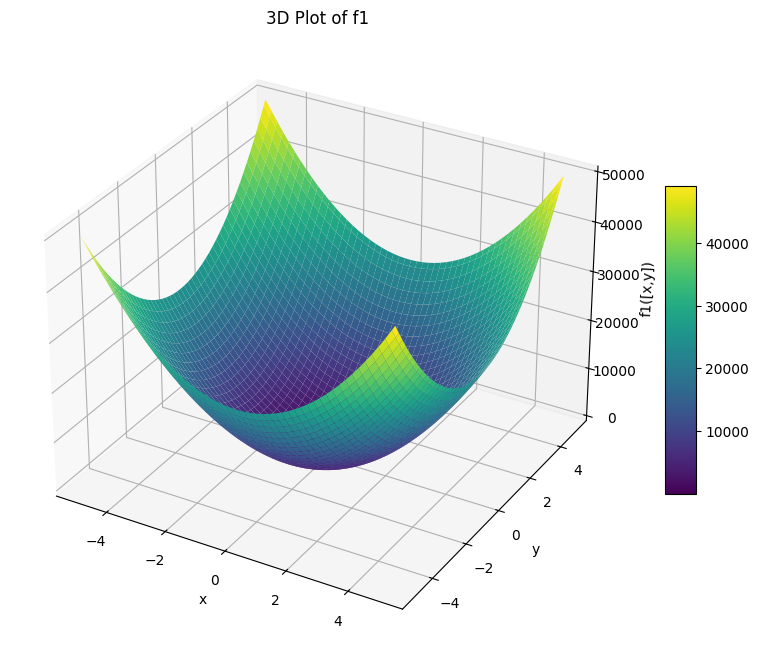

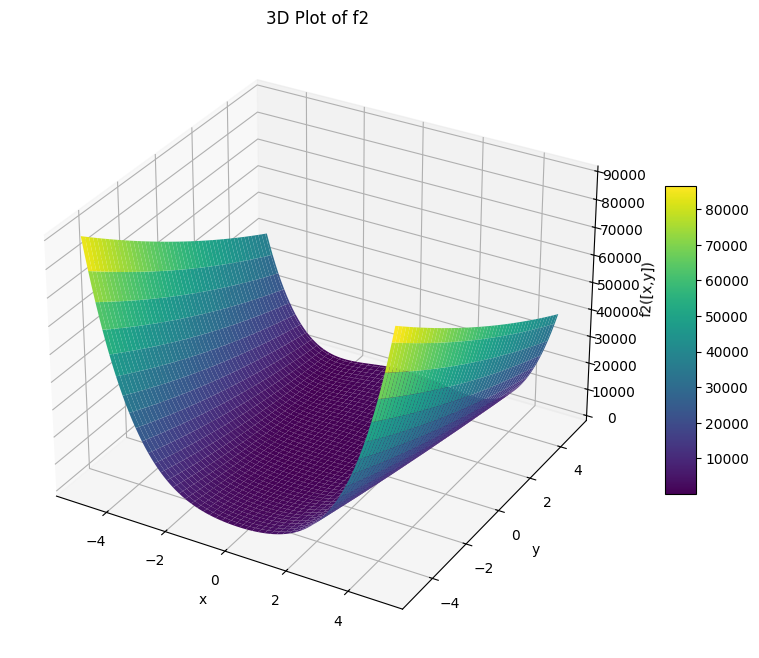

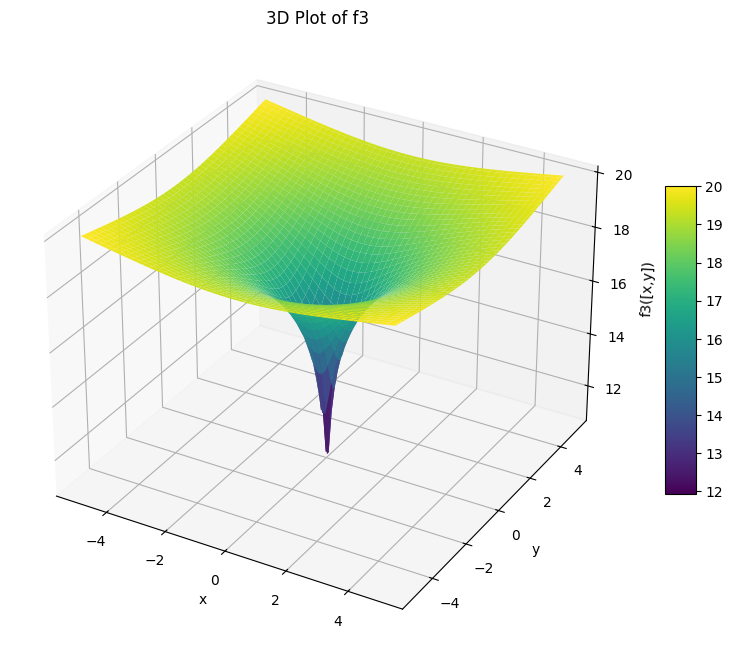

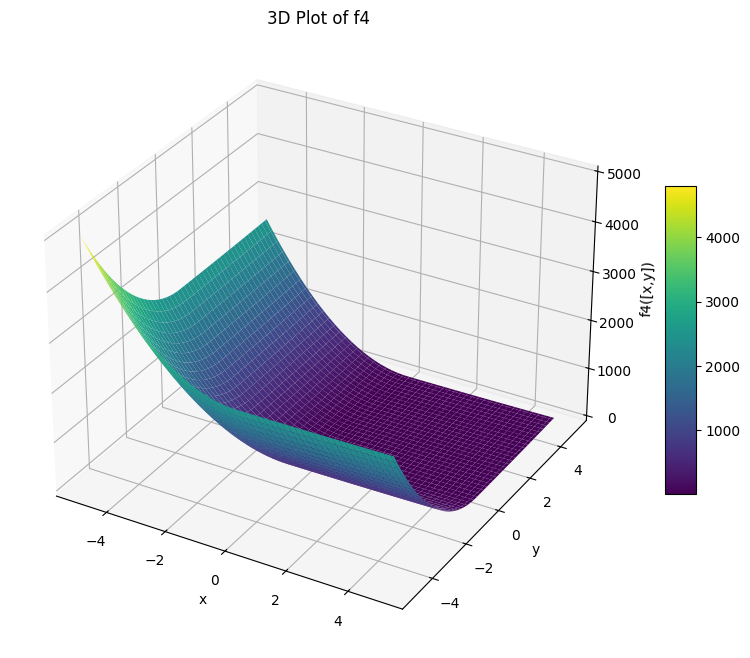

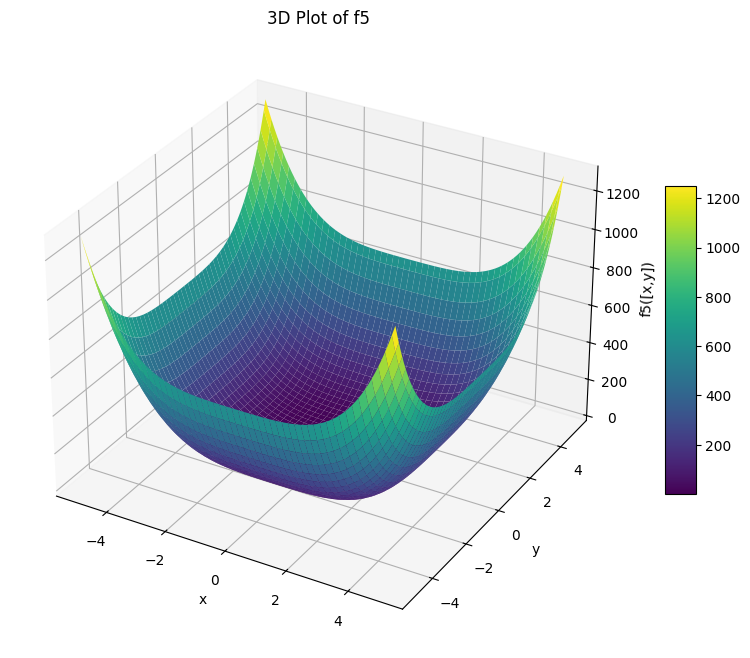

In [64]:
def Fplot(f):
    # Generate grid for x and y
    x_vals = np.linspace(-5, 5, 100)
    y_vals = np.linspace(-5, 5, 100)
    X, Y = np.meshgrid(x_vals, y_vals)

    # Compute Z values for the grid
    Z = np.array([f[1](np.array([[x], [y]])) for x, y in zip(np.ravel(X), np.ravel(Y))])
    Z = Z.reshape(X.shape)
    # Create the 3D plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    # Plot the surface
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
    # Add title and labels
    ax.set_title(f"3D Plot of {f[0]}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel(f"{f[0]}([x,y])")
    # Add color bar
    fig.colorbar(surf, shrink=0.5, aspect=10)
    # Show the plot
    plt.show()

for f in F:  
    Fplot(f)

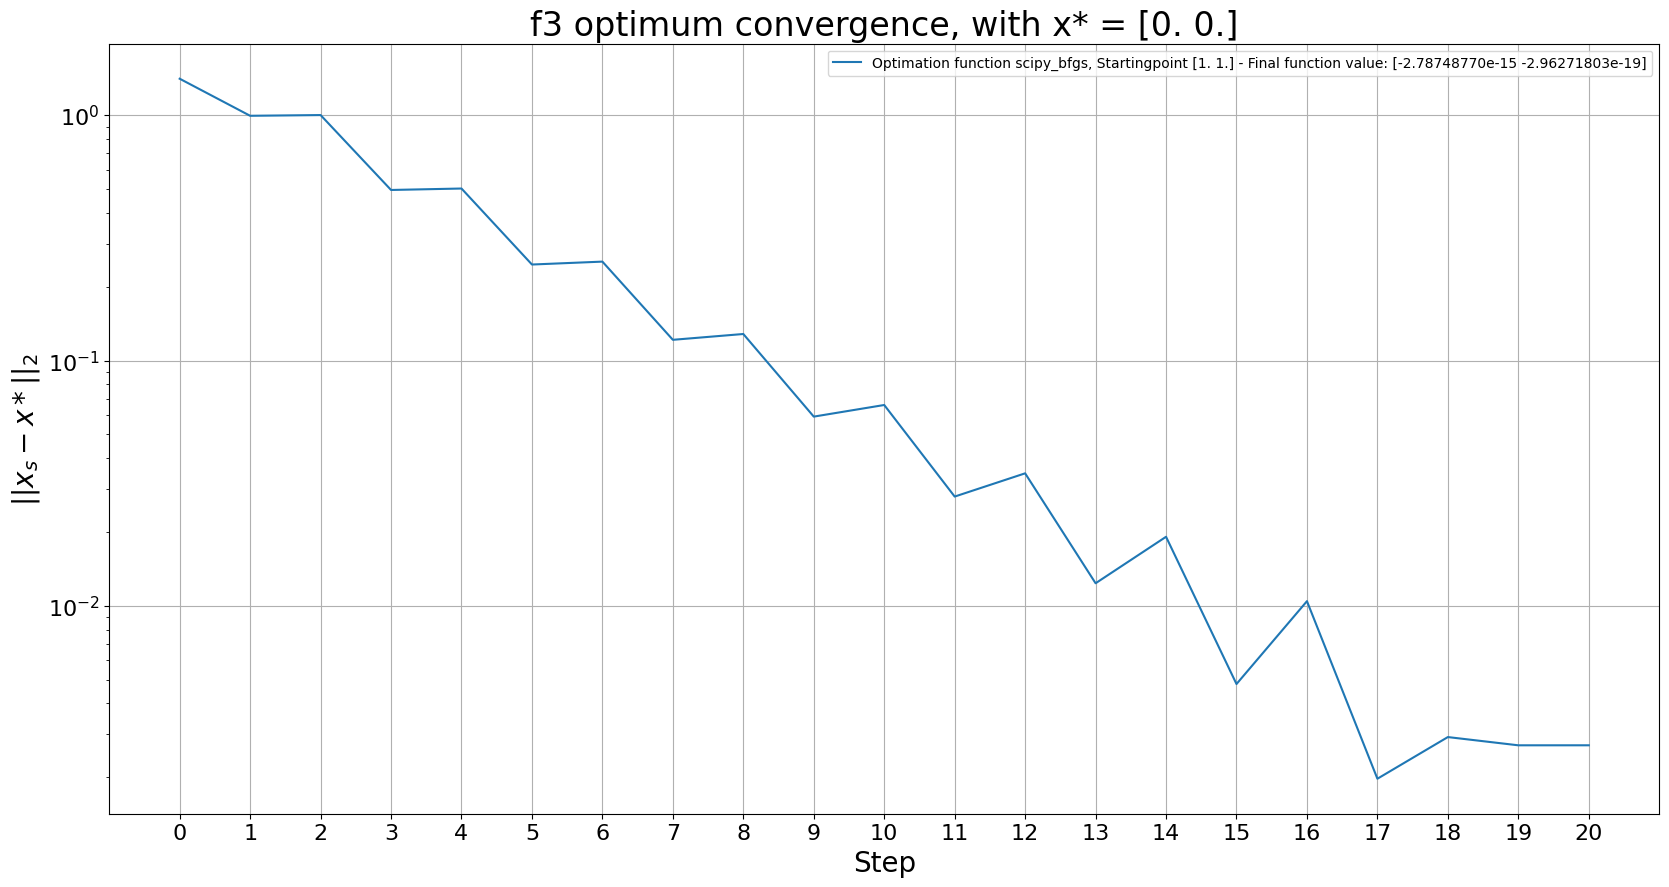

In [89]:
# randomize startingpoints!
def Oplot(f, O):
    x0=np.ones(2)
    plt.figure(figsize=(20, 10))
    plt.yscale("log") #value : {"linear", "log", "symlog", "logit", ...}

    for o in O:
        xs,grad_norms = scipy_trust_region(f[1],f[2],f[3],x0, 1000, 1.e-10)
        N = [np.linalg.norm(v, ord=2) for v in xs-np.full_like(xs, optimal)]
        label = f"Optimation function {o[0]}, Startingpoint {x0} - Final function value: {xs[-1]}"
        plt.plot(range(0,len(xs)), N, label = label)
    plt.legend()    
    plt.title(f"{f[0]} optimum convergence, with x* = {x_opt(f[0], 2)}", fontsize=24)
    plt.xlabel("Step", fontsize=20)
    plt.ylabel("$||x_s - x*||_2$", fontsize=20)
    plt.xticks(range(0,len(xs)), fontsize=16)
    plt.yticks(fontsize=16)
    plt.grid()
    plt.show()

for f in [F3]:  
    Oplot(f, [O1])

In [ ]:
x0=np.array((2,2))#np.ones(2)
#plt.figure(figsize=(32, 32))
plt.yscale("log") #value : {"linear", "log", "symlog", "logit", ...}

for f in F:
    xs,grad_norms = scipy_trust_region(f[1],f[2],f[3],x0, 1000, 1.e-10)
    print("Optimal solution for " + f[0] + ": ", x_opt(f[0], 2))
    N = list() 
    for v in xs-np.full_like(xs, optimal):
        N.append(np.linalg.norm(v, ord=2))
    plt.plot(range(0,len(xs)), N, label = f"{f[0]} - Final function value: {xs[-1]}")

plt.legend()    
plt.title("Blabla", fontsize=24)
plt.xlabel("blabla", fontsize=20)
plt.ylabel("blabla", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid()
plt.show()